# TVET participation and pay: raw-data views of KRI's findings

This notebook investigates two findings in KRI's *The School-to-Work Transition of Young Malaysians* (2018) using respondent-level records. **All visuals are calculated from the released survey CSVs**: Visual 1 uses the in-school module and Visual 2 uses the employer module.

The report used survey weights, but no weight field is present in the recovered public CSVs. The notebook therefore reports transparent **unweighted sample results**, shows the underlying response counts and does not claim to reproduce KRI's population estimates.

[Official report](https://www.krinstitute.org/file/20181205-swts-main-book) | [public dataset page](https://www.krinstitute.org/publications/the-school-to-work-transition-survey-swts-of-young-malaysian) | [local project guide](../README.md)

The original CSVs are checked for integrity and remain unchanged. No synthetic observations or replacement values are created.

**Attribution:** Khazanah Research Institute. 2018. *The School-to-Work Transition of Young Malaysians*. Kuala Lumpur: Khazanah Research Institute. CC BY 3.0. The notebook and visual designs are independent adaptations, not official KRI outputs.

## Read the evidence before drawing a chart

The central tension is that participation is low even though young people already in the labour market see TVET as useful for getting a good job (p.239). The section also describes negative perceptions of the pathway and illustrates a salary gap. It does not establish that either factor causes low enrolment.

The evidence inventory below records the source page and whether an item is a number, a qualitative finding, a recommendation or an international example. Not every claim can become a numerical chart.

In [ ]:
from pathlib import Path
import csv
import json
import textwrap

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from IPython.display import display

# Locate the repository root when started there or from a subdirectory.
candidates = [Path.cwd(), *Path.cwd().parents]
PROJECT = next((p for p in candidates
                if (p / 'raw_data/report/section_evidence.json').exists()), None)
if PROJECT is None:
    raise FileNotFoundError('Run from KRI-app/ or one of its subdirectories.')

RAW = PROJECT / 'raw_data'
OUT = PROJECT / 'notebooks/outputs'
OUT.mkdir(parents=True, exist_ok=True)
evidence = json.loads((RAW / 'report/section_evidence.json').read_text(encoding='utf-8'))
claims = {item['id']: item for item in evidence['claims']}
display(pd.DataFrame(evidence['claims'])[['id', 'page', 'kind', 'claim', 'visual']])
exports = []

def finish(fig, filename, note):
    fig.text(0.055, 0.035, textwrap.fill(note, 135), fontsize=9, va='bottom')
    for extension in ('png', 'svg'):
        path = OUT / f'{filename}.{extension}'
        fig.savefig(path, dpi=180, bbox_inches='tight')
        exports.append(path)
    plt.show()
    plt.close(fig)

,id,page,kind,claim,visual
0,salary_university,239,approximate reported difference,Public-sector maximum salary offers for TVET a...,Topic context only; Visual 2 describes A1=3 sa...
1,salary_spm,239,approximate reported difference,Public-sector maximum salary offers for TVET a...,Topic context only; Visual 2 describes A1=3 sa...
2,ethnicity_chinese,28,reported percentage,1% of Chinese secondary-school students pursue...,Context for 01_school_pathways_by_ethnicity; p...
3,ethnicity_indian,28,reported percentage,4% of Indian secondary-school students pursue ...,Context for 01_school_pathways_by_ethnicity; p...
4,ethnicity_bumiputera,28,reported percentage,15% of Bumiputera secondary-school students pu...,Context for 01_school_pathways_by_ethnicity; p...


## Source checks and analytical boundaries

The source metadata was extracted from KRI's website on **2 October 2026**. The two original CSVs are read without modification. The table below summarises their record and column counts.

**Visual 1:** SWTS_InSchool.csv. The coding manual identifies ethnicity codes 1 and 2 as Malay and Other Bumiputera, 3 as Chinese, 4 as Indian and 5 as Other. The detailed SchoolType1 codes are grouped into the four pathway families used in report Chart 2.3.

**Visual 2:** SWTS_Employer.csv. Report Table 6.7 identifies the relevant measures as maximum offers for school leavers, vocational/technical college graduates, undergraduates and advanced-degree holders. The published manual and questionnaire label A1 = 3 as public sector; this is the selected code. Its label in the released export is not independently confirmed.

The report says probability-sample results were weighted, but neither public CSV contains a weight variable. Both charts are unweighted descriptions of recovered respondents, not nationally representative estimates or exact replications of the published figures. Employer salary fields are self-reported normal offer ranges, not observed earnings, guaranteed starting pay or offers made to every qualification by every employer.

In [2]:
metadata = json.loads((RAW / 'metadata/source_column_definitions.json').read_text(encoding='utf-8'))
source_summary = []
for item in metadata['local_inventory']:
    path = RAW / item['file']
    with path.open(encoding='utf-8-sig', newline='') as handle:
        reader = csv.reader(handle)
        headers = next(reader)
        row_count = sum(1 for _ in reader)
    source_summary.append({'file': path.name, 'records': row_count, 'columns': len(headers),
                           'duplicate_headers': len(headers) - len(set(headers))})
display(pd.DataFrame(source_summary))
print('Source metadata extracted from KRI on 2 October 2026.')

,file,records,columns,duplicate_headers
0,SWTS_Employer.csv,1620,109,0
1,SWTS_InSchool.csv,7026,72,0


Source metadata extracted from KRI on 2 October 2026.


## 1. School pathways by ethnicity in the raw survey

The report's **Chart 2.3** shows the weighted distribution of four school pathways within each ethnicity; the paragraph on printed page 28 summarises only the TVET component. Plotting those three published percentages alone merely repeats the claim.

This chart instead reads all 7,026 rows in SWTS_InSchool.csv, groups the detailed school-type codes into the report's four pathway families, and displays the complete unweighted distribution within each ethnic group. Counts are retained alongside percentages so the particularly small Chinese and Other subsamples are visible.

Because KRI's survey weights were not released in this CSV, differences from the report are expected. The raw sample supports the broad ordering among the three groups named in the claim, but it cannot reproduce the published population percentages exactly.

,respondents,tvet_respondents,tvet_sample_share_percent
ethnicity_group,,,
Bumiputera,5934,704,11.9
Indian,778,60,7.7
Chinese,251,6,2.4
Other,63,2,3.2


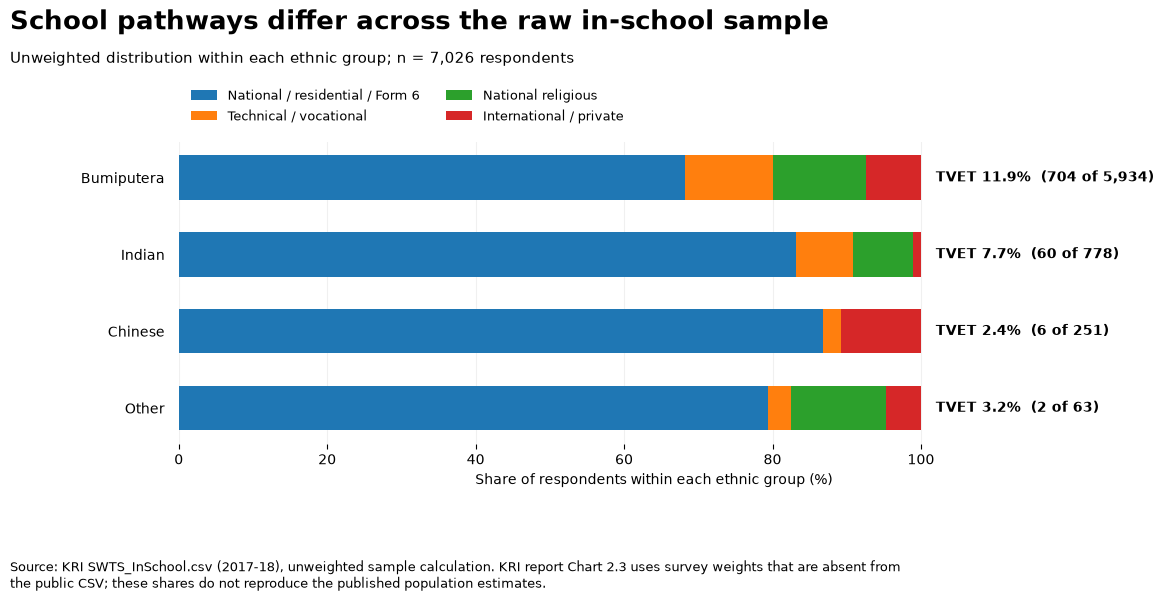

In [3]:
in_school = pd.read_csv(RAW / 'SWTS_InSchool.csv', usecols=['ethnic', 'SchoolType1'])

# KRI coding manual: 1 Malay, 2 Other Bumiputera, 3 Chinese, 4 Indian, 5 Other.
ethnicity_codes = {1: 'Bumiputera', 2: 'Bumiputera', 3: 'Chinese', 4: 'Indian', 5: 'Other'}
# Detailed school codes collapsed to the four pathway families in report Chart 2.3.
school_type_codes = {
    **{code: 'National / residential / Form 6' for code in range(1, 7)},
    7: 'Technical / vocational',
    8: 'National religious', 9: 'National religious',
    10: 'International / private', 11: 'International / private',
}
in_school['ethnicity_group'] = in_school['ethnic'].map(ethnicity_codes)
in_school['school_pathway'] = in_school['SchoolType1'].map(school_type_codes)
assert in_school[['ethnicity_group', 'school_pathway']].notna().all().all()

group_order = ['Bumiputera', 'Indian', 'Chinese', 'Other']
pathway_order = ['National / residential / Form 6', 'Technical / vocational',
                 'National religious', 'International / private']
school_counts = (pd.crosstab(in_school['ethnicity_group'], in_school['school_pathway'])
                 .reindex(index=group_order, columns=pathway_order, fill_value=0))
school_shares = school_counts.div(school_counts.sum(axis=1), axis=0).mul(100)
visual1_summary = pd.DataFrame({
    'respondents': school_counts.sum(axis=1),
    'tvet_respondents': school_counts['Technical / vocational'],
    'tvet_sample_share_percent': school_shares['Technical / vocational'].round(1),
})
display(visual1_summary)

fig, ax = plt.subplots(figsize=(12.5, 6.3))
fig.subplots_adjust(left=0.19, right=0.95, top=0.75, bottom=0.27)
fig.suptitle('School pathways differ across the raw in-school sample',
             x=0.055, y=0.96, ha='left', fontsize=19, weight='bold')
fig.text(0.055, 0.875, 'Unweighted distribution within each ethnic group; n = 7,026 respondents',
         fontsize=11)

left = pd.Series(0.0, index=group_order)
for pathway in pathway_order:
    values = school_shares[pathway]
    ax.barh(group_order, values, left=left, height=0.58,
            label=pathway)
    left = left + values

for y, group in enumerate(group_order):
    share = visual1_summary.loc[group, 'tvet_sample_share_percent']
    count = visual1_summary.loc[group, 'tvet_respondents']
    total = visual1_summary.loc[group, 'respondents']
    ax.text(102, y, f'TVET {share:.1f}%  ({count:,} of {total:,})',
            va='center', fontsize=10.2, weight='bold')

ax.invert_yaxis()
ax.set(xlim=(0, 128), xlabel='Share of respondents within each ethnic group (%)')
ax.set_xticks([0, 20, 40, 60, 80, 100])
ax.grid(axis='x', alpha=0.18)
ax.set_axisbelow(True)
ax.tick_params(axis='y', length=0, pad=10)
ax.legend(ncol=2, loc='lower left', bbox_to_anchor=(0, 1.02), frameon=False, fontsize=9.5)
for spine in ax.spines.values(): spine.set_visible(False)
finish(fig, '01_school_pathways_by_ethnicity',
       'Source: KRI SWTS_InSchool.csv (2017-18), unweighted sample calculation. KRI report Chart 2.3 uses survey weights that are absent from the public CSV; these shares do not reproduce the published population estimates.')

## 2. Maximum salary offers for A1 = 3

The coding manual (PDF p.32) and employer questionnaire (PDF p.5) label **A1 = 3** as **Public sector/government agency**. This visual describes the **405 employer records** with that code in the released CSV. The export-specific label mapping is unconfirmed, so the code and questionnaire label are stated explicitly.

Each dot is an employer's valid maximum monthly offer for the indicated qualification. The orange diamond is the **unweighted mean of those maximum offers**, and the green line is their **median**. Neither summary is the largest individual offer. The table also includes minimum and maximum observed responses so these statistics can be distinguished.

Blank and non-numeric responses are excluded; valid counts differ by qualification. The school-leaver header and the questionnaire's low-skilled wording are retained together. These are employer-reported offers, not observed graduate earnings, guaranteed pay or estimates of the effect of qualifications.

The report provides context for the topic, but this chart is a description of the released sample and does not attempt to reproduce its rounded wage-gap claim.

405 employers; questionnaire label: Public sector/government agency (CSV mapping unconfirmed)


,responses,mean_rm,median_rm,minimum_rm,maximum_rm
qualification,,,,,
School leaver / low-skilled,298,1824.0,1500.0,900.0,5000.0
Vocational / technical college,159,2235.0,1800.0,800.0,8000.0
University undergraduate,214,3000.0,2500.0,800.0,7500.0
University postgraduate,122,3030.0,2500.0,1000.0,6500.0


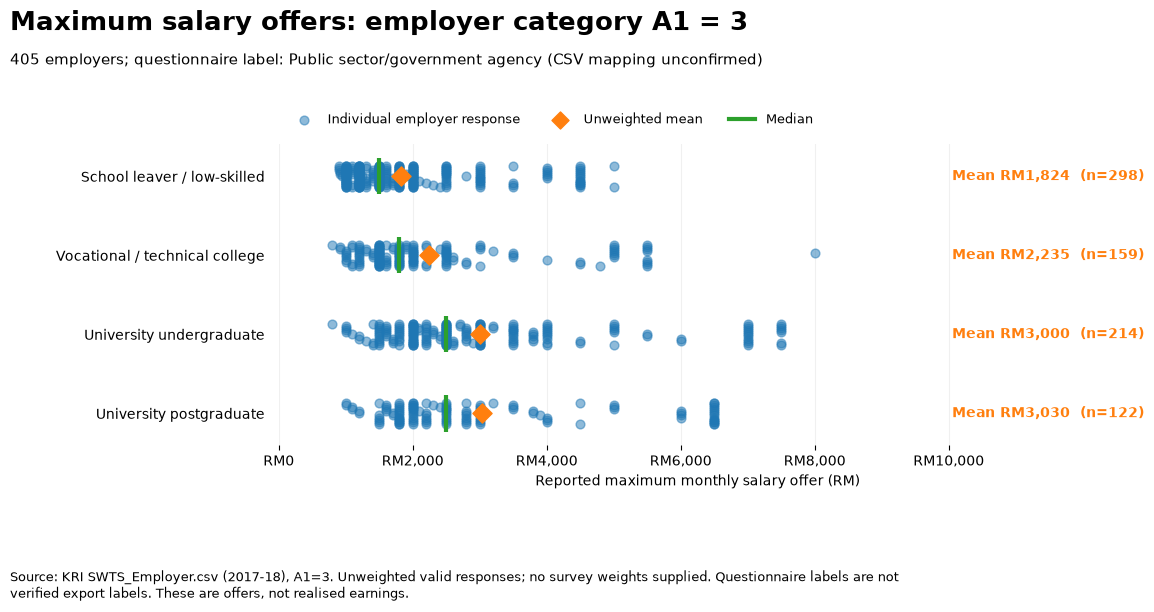

In [4]:
salary_fields = {
    'C5d_schoollever_maximum': 'School leaver / low-skilled',
    'C5c_college_maximum': 'Vocational / technical college',
    'C5a_undergraduate_maximum': 'University undergraduate',
    'C5b_postgraduate_maximum': 'University postgraduate',
}
employer = pd.read_csv(RAW / 'SWTS_Employer.csv', usecols=['A1', *salary_fields])
qualification_order = list(salary_fields.values())
salary_rows_by_code, salary_summaries_by_code = {}, {}

def plot_salary_code(code, filename, instrument_label):
    selected = employer.loc[employer['A1'].eq(code), list(salary_fields)].copy()
    selected = selected.apply(pd.to_numeric, errors='coerce')
    offers = (selected.rename(columns=salary_fields)
              .melt(var_name='qualification', value_name='maximum_offer_rm').dropna())
    summary = (offers.groupby('qualification')['maximum_offer_rm']
               .agg(responses='count', mean_rm='mean', median_rm='median',
                    minimum_rm='min', maximum_rm='max')
               .reindex(qualification_order))
    key = code
    salary_rows_by_code[key] = selected
    salary_summaries_by_code[key] = summary
    title = ('Maximum salary offers: all employer types pooled' if code is None
             else f'Maximum salary offers: employer category A1 = {code}')
    subtitle = (f'{len(selected):,} employers; no A1 filter; includes the respondent with missing A1' if code is None
                else f'{len(selected)} employers; questionnaire label: {instrument_label} (CSV mapping unconfirmed)')
    print(subtitle)
    display(summary.round(0))

    fig, ax = plt.subplots(figsize=(12.5, 6.4))
    fig.subplots_adjust(left=0.27, right=0.94, top=0.75, bottom=0.28)
    fig.suptitle(title,
                 x=0.055, y=0.96, ha='left', fontsize=19, weight='bold')
    fig.text(0.055, 0.875,
             subtitle,
             fontsize=10.5)
    for y, qualification in enumerate(qualification_order):
        values = offers.loc[offers['qualification'].eq(qualification), 'maximum_offer_rm'].sort_values().to_numpy()
        offsets = pd.Series(range(len(values))).mod(11).sub(5).mul(0.027)
        ax.scatter(values, y + offsets, s=40, color='C0', alpha=0.5, zorder=2)
        mean = summary.loc[qualification, 'mean_rm']
        median = summary.loc[qualification, 'median_rm']
        count = summary.loc[qualification, 'responses']
        if pd.notna(mean):
            ax.vlines(median, y - 0.23, y + 0.23, color='C2', linewidth=3, zorder=3)
            ax.scatter(mean, y, marker='D', s=95, color='C1', zorder=4)
            label = f'Mean RM{mean:,.0f}  (n={int(count)})'
        else:
            label = 'No valid responses'
        ax.text(10050, y, label, va='center', fontsize=10.2, weight='bold', color='C1')
    ax.scatter([], [], s=40, color='C0', alpha=0.5, label='Individual employer response')
    ax.scatter([], [], marker='D', s=75, color='C1', label='Unweighted mean')
    ax.plot([], [], color='C2', linewidth=3, label='Median')
    ax.set(yticks=range(len(qualification_order)), yticklabels=qualification_order,
           xlim=(0, 12500), xlabel='Reported maximum monthly salary offer (RM)')
    ax.invert_yaxis()
    ax.set_xticks([0, 2000, 4000, 6000, 8000, 10000])
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'RM{x:,.0f}'))
    ax.grid(axis='x', alpha=0.18)
    ax.set_axisbelow(True)
    ax.tick_params(axis='y', length=0, pad=10)
    ax.legend(ncol=3, loc='lower left', bbox_to_anchor=(0, 1.02), frameon=False, fontsize=9.5)
    for spine in ax.spines.values(): spine.set_visible(False)
    finish(fig, filename,
           ('Source: KRI SWTS_Employer.csv (2017-18), all employer records pooled. Unweighted valid responses; mix and valid n vary by qualification. Not a replication of Table 6.7 or realised earnings.' if code is None
            else f'Source: KRI SWTS_Employer.csv (2017-18), A1={code}. Unweighted valid responses; no survey weights supplied. Questionnaire labels are not verified export labels. These are offers, not realised earnings.'))

plot_salary_code(3, '02_salary_offers_a1_3', 'Public sector/government agency')

## Interpretation and app handoff

Visual 1 describes school pathways within each ethnicity. Visual 2 describes maximum salary offers among the records with A1 = 3, using individual responses, unweighted means and medians. Its summary table records valid response counts and the observed range for each qualification.

Both charts describe the released sample. They do not reproduce the report's weighted population estimates, establish the causes of observed differences or identify a causal return to education. The published questionnaire's label for A1 = 3 is recorded alongside the unresolved export-mapping caveat.

In [5]:
assert len(in_school) == 7026
assert int(visual1_summary['respondents'].sum()) == 7026
assert len(employer) == 1620
assert len(salary_rows_by_code[3]) == int(employer['A1'].eq(3).sum()) == 405
for code in [3]:
    expected = salary_rows_by_code[code].notna().sum().tolist()
    assert salary_summaries_by_code[code]['responses'].tolist() == expected
assert len(exports) == 4 and all(path.is_file() and path.stat().st_size > 0 for path in exports)
display(pd.DataFrame({'export': [str(path.relative_to(PROJECT)) for path in exports]}))
print('Two figures exported in PNG and SVG. Visual 3 selects A1 = 3; its published questionnaire label is public sector.')

,export
0,notebooks\outputs\01_school_pathways_by_ethnic...
1,notebooks\outputs\01_school_pathways_by_ethnic...
2,notebooks\outputs\02_salary_offers_a1_3.png
3,notebooks\outputs\02_salary_offers_a1_3.svg


Two figures exported in PNG and SVG. Visual 3 selects A1 = 3; its published questionnaire label is public sector.


## Sources and reproduction

- **Visual 1:** KRI's SWTS_InSchool.csv, 7,026 respondent records. Ethnicity codes come from KRI's [SWTS coding manual](https://kri-public-data.s3.ap-southeast-1.amazonaws.com/SWTS/20170727_SWTS%20Coding%20Manual.pdf); school pathways follow report Chart 2.3.
- **Visual 2:** KRI's SWTS_Employer.csv, A1 = 3 (405 employers; public-sector label in the published questionnaire, CSV mapping unconfirmed) and the four maximum-offer fields corresponding to report Table 6.7. Qualification wording is checked against the [employer questionnaire](https://kri-public-data.s3.ap-southeast-1.amazonaws.com/SWTS/20170731_SWTS%20Employer%20Survey%20v10.pdf).
- **Claim origins:** KRI (2018), *The School-to-Work Transition of Young Malaysians*, Chart 2.3, Table 6.7 and printed p.239. [Official report](https://www.krinstitute.org/file/20181205-swts-main-book); [local project guide](../README.md).
- **Weighting boundary:** Appendix 1 says probability-sample analyses use design and non-response weights. No weight column exists in either released CSV, so all visuals report unweighted sample results and do not reproduce the published population estimates.

The [public dataset page](https://www.krinstitute.org/publications/the-school-to-work-transition-survey-swts-of-young-malaysian) documents the survey modules and links their instruments. Select **KRI-app (.venv)** and **Run All**. PNG/SVG outputs are written to `notebooks/outputs/`; no derived CSV is created.